# **IMPORT LIBARIES AND LOAD DATASETS**

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the datasets
beaches = gpd.read_file("toronto-beaches-water-quality - 4326.geojson")
weather = pd.read_csv("toronto_weather_daily_2007_2025.csv")
print (beaches.columns)
print (weather.columns)


Index(['_id', 'beachId', 'beachName', 'siteName', 'collectionDate', 'eColi',
       'comments', 'geometry'],
      dtype='object')
Index(['date', 'temp_mean', 'precip', 'year', 'month'], dtype='object')


# **DATA CLEANING CHECK**

In [4]:
#missing values
print("Missing values in beaches dataset:")
print(beaches.isna().sum())
print("--"*20)
print("Missing values in weather dataset:")
print(weather.isna().sum())
print("--"*20)
#drop rows with missing values in beaches dataset
beaches = beaches.dropna()

#duplicate values
print("Duplicate values in beaches dataset:",beaches.duplicated().sum())
print("--"*20)
print("Duplicate values in weather dataset:",weather.duplicated().sum())
print("--"*20)

#outliers percentage for numeric columns in beaches dataset
print("Outlier Percentage on beaches dataset")
numeric_cols = beaches.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    q1 = beaches[col].quantile(0.25)
    q3 = beaches[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = beaches[(beaches[col] < lower_bound) | (beaches[col] > upper_bound)]
    outlier_percentage = len(outliers) / len(beaches) * 100
    print(f"{col}: {outlier_percentage:.2f}% outliers")
print("--"*20)

#outliers percentage for numeric columns in weather dataset
print("Outlier Percentage on weather dataset")
numeric_cols_weather = weather.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols_weather:
    q1 = weather[col].quantile(0.25)
    q3 = weather[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = weather[(weather[col] < lower_bound) | (weather[col] > upper_bound)]
    outlier_percentage = len(outliers) / len(weather) * 100
    print(f"{col}: {outlier_percentage:.2f}% outliers")
print("--"*20)


Missing values in beaches dataset:
_id                  0
beachId              0
beachName            0
siteName             0
collectionDate       0
eColi             9329
comments             0
geometry             0
dtype: int64
----------------------------------------
Missing values in weather dataset:
date         0
temp_mean    0
precip       0
year         0
month        0
dtype: int64
----------------------------------------
Duplicate values in beaches dataset: 0
----------------------------------------
Duplicate values in weather dataset: 0
----------------------------------------
Outlier Percentage on beaches dataset
eColi: 14.10% outliers
----------------------------------------
Outlier Percentage on weather dataset
temp_mean: 0.00% outliers
precip: 14.49% outliers
year: 0.00% outliers
month: 0.00% outliers
----------------------------------------


In [5]:
# capeting ecolI outliers in beaches dataset
for col in numeric_cols:
    Q1 = beaches[col].quantile(0.25)
    Q3 = beaches[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    beaches[col] = beaches[col].clip(lower=lower_bound, upper=upper_bound)


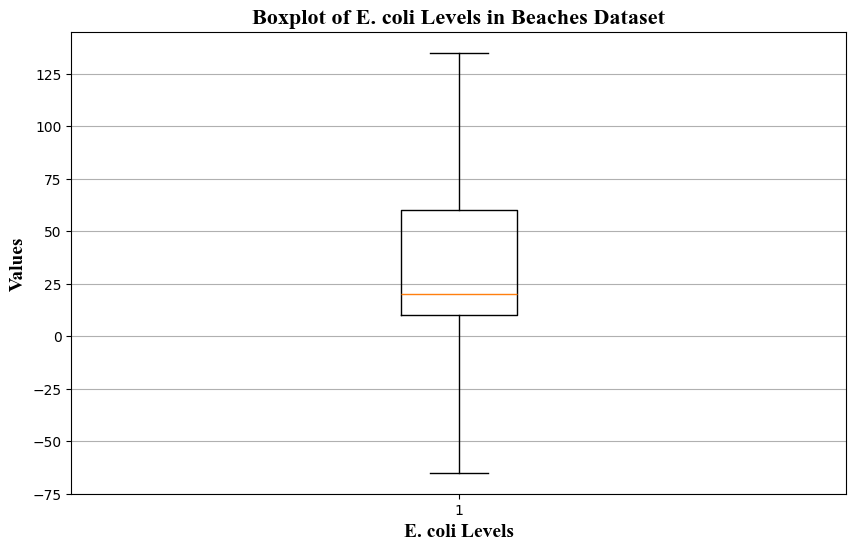

In [6]:
#boxplot of eColi levels in beaches dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.boxplot(beaches['eColi'])
plt.title('Boxplot of E. coli Levels in Beaches Dataset', fontsize=16, fontweight='bold', family='Times New Roman')
plt.xlabel('E. coli Levels', fontsize=14, fontweight='bold', family='Times New Roman')
plt.ylabel('Values', fontsize=14, fontweight='bold', family='Times New Roman')
plt.grid(axis='y')
plt.show()

# **MODEL DESIGN**

In [ ]:
#Merging datasets on date
beaches['date'] = pd.to_datetime(beaches['collectionDate']).dt.date
weather['date'] = pd.to_datetime(weather['date']).dt.date
df = beaches.merge(weather, on='date', how='left')

# Create a binary flag for unsafe water quality based on eColi levels according to public health guidelines
df['unsafe'] = (df['eColi'] > 100).astype(int)

# Calculate eColi levels statistics by beach
risk_by_beach = df.groupby('beachName').agg(
    mean_ecoli=('eColi','mean'),
    max_ecoli=('eColi','max'),
    unsafe_rate=('unsafe','mean'),
    n_samples=('eColi','count')
).reset_index()

# beaches with highest unsafe rates
print("Top 5 beaches with highest unsafe rates:")
risk_by_beach = risk_by_beach.sort_values('unsafe_rate', ascending=False)
print(risk_by_beach.head())



Top 5 beaches with highest unsafe rates:
                      beachName  mean_ecoli  max_ecoli  unsafe_rate  n_samples
7               Sunnyside Beach   72.304333      135.0     0.358793      11862
6  Marie Curtis Park East Beach   67.812500      135.0     0.355558       9104
5               Kew Balmy Beach   45.380777      135.0     0.195236      11965
1           Centre Island Beach   48.026920      135.0     0.195143       9101
0          Bluffer's Beach Park   36.041302      135.0     0.130229       9491


In [8]:
# Analyze the relationship between precipitation and unsafe water quality
high_rain = df[df['precip'] > 10]['unsafe'].mean()
low_rain = df[df['precip'] <= 10]['unsafe'].mean()

print("Unsafe flag propapility with heavy rain (>10mm):", round(high_rain*100, 2), "%")
print("Unsafe flag propapility withouth heavy rain (<=10mm):",round(low_rain*100, 2), "%")


Unsafe flag propapility with heavy rain (>10mm): 28.98 %
Unsafe flag propapility withouth heavy rain (<=10mm): 16.23 %


In [9]:
# Analyze the relationship between temperature and unsafe water quality
hot_days = df[df['temp_mean'] > 22]['unsafe'].mean()
cool_days = df[df['temp_mean'] <= 22]['unsafe'].mean()

print("Unsafe flag propapility with high temperature (>22°C):", round(hot_days*100, 2), "%")
print("Unsafe flag propapility with low temperature (<=22°C):",round(cool_days*100, 2), "%")


Unsafe flag propapility with high temperature (>22°C): 18.79 %
Unsafe flag propapility with low temperature (<=22°C): 16.38 %


In [ ]:
# Analyze the relationship between month and unsafe water quality
monthly_risk = df.groupby('month')['unsafe'].mean().sort_values(ascending=False) * 100

print("Unsafe flag propapility by month (%):")
print(monthly_risk)



# **RANKING DEVELOPMENT**

In [28]:
# Normalize the metrics for risk scoring
risk_by_beach['norm_unsafe'] = risk_by_beach['unsafe_rate']
risk_by_beach['norm_ecoli'] = risk_by_beach['mean_ecoli'] / risk_by_beach['mean_ecoli'].max()
risk_by_beach['norm_samples'] = risk_by_beach['n_samples'] / risk_by_beach['n_samples'].max()

# Score ponderated
risk_by_beach['risk_score'] = (
    0.5 * risk_by_beach['norm_unsafe'] +
    0.3 * risk_by_beach['norm_ecoli'] +
    0.2 * risk_by_beach['norm_samples']
)


# **RESULTS**

Risk scores and priority classifications by beach:
                      beachName  mean_ecoli  max_ecoli  unsafe_rate  \
7               Sunnyside Beach   72.304333      135.0     0.358793   
6  Marie Curtis Park East Beach   67.812500      135.0     0.355558   
5               Kew Balmy Beach   45.380777      135.0     0.195236   
1           Centre Island Beach   48.026920      135.0     0.195143   
0          Bluffer's Beach Park   36.041302      135.0     0.130229   
9              Woodbine Beaches   32.990473      135.0     0.108232   
8           Ward's Island Beach   31.761641      135.0     0.099099   
2                  Cherry Beach   30.110076      135.0     0.087371   
4          Hanlan's Point Beach   29.615898      135.0     0.082003   
3         Gibraltar Point Beach   26.378049      135.0     0.059534   

   n_samples  norm_unsafe  norm_ecoli  norm_samples  risk_score priority  
7      11862     0.358793    1.000000      0.991392    0.677675     High  
6       9104     

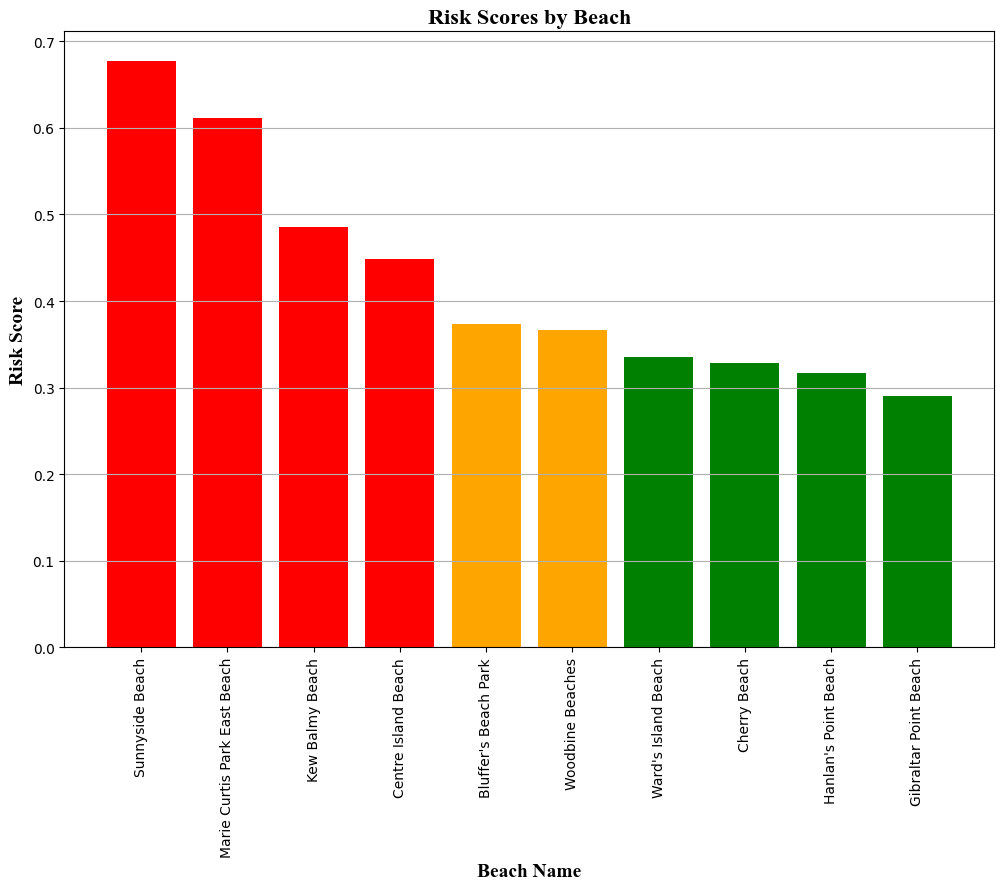

In [29]:
# Classify beaches into risk categories based on quantiles
risk_by_beach['priority'] = pd.qcut(
    risk_by_beach['risk_score'],
    q=3,
    labels=['Low','Medium','High']
)


# Print the risk scores and priority classifications with the number of hot days and heavy rain days
print("Risk scores and priority classifications by beach:")
print(risk_by_beach.sort_values('risk_score', ascending=False))



#Plotting the risk scores by beach
plt.figure(figsize=(12, 8))
plt.bar(risk_by_beach['beachName'], risk_by_beach['risk_score'], 
        color=['red' if x == 'High' else 'orange' if x == 'Medium' else 'green' for x in risk_by_beach['priority']])
plt.xticks(rotation=90)
plt.title('Risk Scores by Beach', fontsize=16, fontweight='bold', family='Times New Roman')
plt.xlabel('Beach Name', fontsize=14, fontweight='bold', family='Times New Roman')
plt.ylabel('Risk Score', fontsize=14, fontweight='bold', family='Times New Roman')
plt.grid(axis='y')
plt.show()


# **EXPORT DATA**

In [30]:
risk_by_beach.to_csv("beach_risk_ranking.csv", index=False)